# 🧹 Data Cleaning — Dirty Café Sales
**Oasis Infobyte Internship · Data Analytics · Level 1 — Task 3**

**Objective:** take a deliberately messy dataset and transform it, step by step, into a clean, analysis-ready dataset — documenting and justifying every decision.

**Dataset:** *Dirty Café Sales* (Kaggle) — 10,000 transactions of a café in 2023.

| Column | Meaning | Expected type |
|---|---|---|
| Transaction ID | Unique ID of the transaction | string |
| Item | Product sold | string |
| Quantity | Number of units | integer |
| Price Per Unit | Unit price | float |
| Total Spent | Quantity × Price Per Unit | float |
| Payment Method | Cash / Credit Card / Digital Wallet | string |
| Location | In-store / Takeaway | string |
| Transaction Date | Date of the transaction | datetime |

**Plan**
1. Data quality report
2. Standardisation (placeholder values & text formatting)
3. Data type correction
4. Missing data handling
5. Duplicate removal
6. Outlier detection
7. Final validation
8. Before vs. after summary
9. Export of the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

raw = pd.read_csv("data/raw.csv")
df = raw.copy()          # we keep `raw` untouched for the before/after comparison
print("Shape:", df.shape)
df.head(10)

Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 1. Data Quality Report
Before changing anything, we measure **what is wrong** with the data: missing values, placeholder values, duplicates, wrong data types and value anomalies.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


**Observation:** every column is stored as text (`str`), even `Quantity`, `Price Per Unit`, `Total Spent` and `Transaction Date`. This already tells us that some cells contain non-numeric / non-date values.

### 1.1 Missing values and placeholder values

In [3]:
PLACEHOLDERS = ["ERROR", "UNKNOWN"]

quality = pd.DataFrame({
    "NaN": df.isna().sum(),
    "ERROR": (df == "ERROR").sum(),
    "UNKNOWN": (df == "UNKNOWN").sum(),
})
quality["Total missing-like"] = quality.sum(axis=1)
quality["% of rows"] = (quality["Total missing-like"] / len(df) * 100).round(1)
quality.sort_values("Total missing-like", ascending=False)

,NaN,ERROR,UNKNOWN,Total missing-like,% of rows
Location,3265,358,338,3961,39.6
Payment Method,2579,306,293,3178,31.8
Item,333,292,344,969,9.7
Price Per Unit,179,190,164,533,5.3
Total Spent,173,164,165,502,5.0
Quantity,138,170,171,479,4.8
Transaction Date,159,142,159,460,4.6
Transaction ID,0,0,0,0,0.0


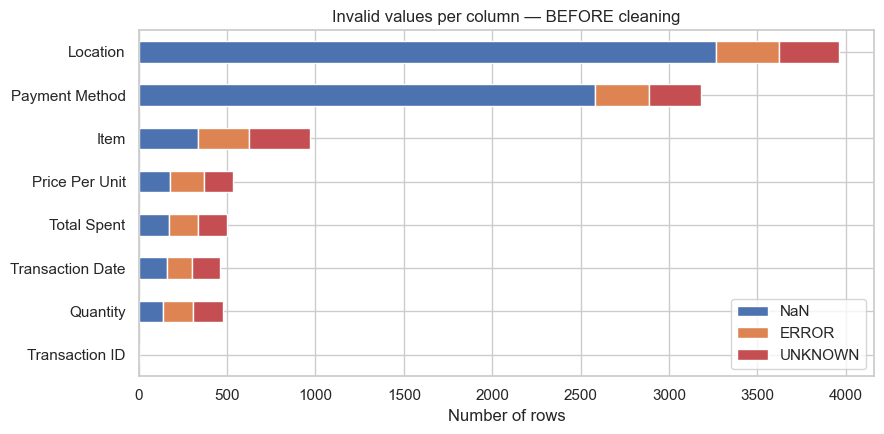

In [4]:
ax = quality[["NaN", "ERROR", "UNKNOWN"]].sort_values("NaN").plot(
    kind="barh", stacked=True, figsize=(9, 4.5), color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_title("Invalid values per column — BEFORE cleaning")
ax.set_xlabel("Number of rows")
plt.tight_layout()
plt.savefig("images/missing_before.png", dpi=120)
plt.show()

**Observations:**
- Missing information comes in **three forms**: real empty cells (`NaN`), and two text placeholders, `"ERROR"` and `"UNKNOWN"`. A simple `isna()` would **miss** the placeholders, so they must be treated as missing too.
- `Location` (~40 %) and `Payment Method` (~32 %) are the most affected columns.
- The numeric columns and the date are affected in only ~4–5 % of rows each.

### 1.2 Duplicates

In [5]:
print("Fully duplicated rows      :", df.duplicated().sum())
print("Duplicated Transaction IDs :", df["Transaction ID"].duplicated().sum())
print("IDs matching 'TXN_' + 7 digits:", df["Transaction ID"].str.match(r"^TXN_\d{7}$").mean() * 100, "%")

Fully duplicated rows      : 0
Duplicated Transaction IDs : 0
IDs matching 'TXN_' + 7 digits: 100.0 %


### 1.3 Data type issues

In [6]:
# Which values prevent the numeric / date columns from being converted?
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    bad = df.loc[pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna(), col]
    print(f"{col:<16} non-numeric values: {bad.value_counts().to_dict()}")

bad_dates = df.loc[pd.to_datetime(df["Transaction Date"], errors="coerce", format="%Y-%m-%d").isna()
                   & df["Transaction Date"].notna(), "Transaction Date"]
print(f"{'Transaction Date':<16} non-date values   : {bad_dates.value_counts().to_dict()}")

Quantity         non-numeric values: {'UNKNOWN': 171, 'ERROR': 170}
Price Per Unit   non-numeric values: {'ERROR': 190, 'UNKNOWN': 164}
Total Spent      non-numeric values: {'UNKNOWN': 165, 'ERROR': 164}
Transaction Date non-date values   : {'UNKNOWN': 159, 'ERROR': 142}


### 1.4 Value range anomalies and business rules

In [7]:
num = df[["Quantity", "Price Per Unit", "Total Spent"]].apply(pd.to_numeric, errors="coerce")
display(num.describe().T)

dates = pd.to_datetime(df["Transaction Date"], errors="coerce")
print("Date range:", dates.min().date(), "→", dates.max().date())

# Business rule 1: Total Spent = Quantity × Price Per Unit
complete = num.dropna()
rule_ok = np.isclose(complete["Quantity"] * complete["Price Per Unit"], complete["Total Spent"])
print(f"Rows where Total = Quantity × Price: {rule_ok.mean() * 100:.1f} % (of {len(complete)} complete rows)")

,count,mean,std,min,25%,50%,75%,max
Quantity,9521.0,3.028463,1.419007,1.0,2.0,3.0,4.0,5.0
Price Per Unit,9467.0,2.949984,1.278450,1.0,2.0,3.0,4.0,5.0
Total Spent,9498.0,8.924352,6.009919,1.0,4.0,8.0,12.0,25.0


Date range: 2023-01-01 → 2023-12-31
Rows where Total = Quantity × Price: 100.0 % (of 8544 complete rows)


In [8]:
# Business rule 2: does every item always have the same price?
items_prices = pd.DataFrame({"Item": df["Item"], "Price": num["Price Per Unit"]})
items_prices = items_prices[~items_prices["Item"].isin(PLACEHOLDERS)].dropna()
items_prices.groupby("Item")["Price"].agg(["min", "max", "nunique"])

,min,max,nunique
Item,,,
Cake,3.0,3.0,1
Coffee,2.0,2.0,1
Cookie,1.0,1.0,1
Juice,3.0,3.0,1
Salad,5.0,5.0,1
Sandwich,4.0,4.0,1
Smoothie,4.0,4.0,1
Tea,1.5,1.5,1


In [9]:
print("Unique values of the categorical columns:")
for col in ["Item", "Payment Method", "Location"]:
    print(f"  {col:<15}", sorted(df[col].dropna().unique()))

Unique values of the categorical columns:
  Item            ['Cake', 'Coffee', 'Cookie', 'ERROR', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea', 'UNKNOWN']
  Payment Method  ['Cash', 'Credit Card', 'Digital Wallet', 'ERROR', 'UNKNOWN']
  Location        ['ERROR', 'In-store', 'Takeaway', 'UNKNOWN']


**Observations (quality report summary):**
- **No negative or impossible values**: quantities are between 1 and 5, prices between 1 and 5, totals between 1 and 25, and all dates fall in 2023.
- **Total = Quantity × Price is true for 100 % of complete rows**, and **each item always has the same price** (a fixed menu). These two rules are very valuable: they will let us **recover** many missing values *with certainty* instead of guessing them.
- The categorical columns have no spelling variants (e.g. no `"coffee"` vs `"Coffee"`) — the only problems are the placeholders.
- No duplicated rows and no duplicated IDs.

## 2. Standardisation
### 2.1 Placeholder values → `NaN`
`"ERROR"` and `"UNKNOWN"` carry no information: they mean *"we don't know the value"*. We convert them into a real `NaN` so that pandas treats all missing data in **one consistent way**.

In [10]:
df = df.replace(PLACEHOLDERS, np.nan)
print("Missing values per column after converting placeholders:")
df.isna().sum()

Missing values per column after converting placeholders:


Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

### 2.2 Text formatting
Even though no inconsistent spelling was found, we apply a defensive standardisation (strip spaces, harmonise case) so that the pipeline would still work on new data such as `" coffee "` or `"CASH"`.

In [11]:
CANONICAL = {
    "Item": ["Cake", "Coffee", "Cookie", "Juice", "Salad", "Sandwich", "Smoothie", "Tea"],
    "Payment Method": ["Cash", "Credit Card", "Digital Wallet"],
    "Location": ["In-store", "Takeaway"],
}

for col, values in CANONICAL.items():
    mapping = {v.lower().replace(" ", "").replace("-", ""): v for v in values}
    key = df[col].str.strip().str.lower().str.replace(r"[\s\-]", "", regex=True)
    df[col] = key.map(mapping)            # anything not in the canonical list becomes NaN
    print(f"{col:<15} → {sorted(df[col].dropna().unique())}")

Item            → ['Cake', 'Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea']
Payment Method  → ['Cash', 'Credit Card', 'Digital Wallet']


Location        → ['In-store', 'Takeaway']


The text columns now only contain the official category names.

## 3. Data Type Correction
| Column | Before | After | Why |
|---|---|---|---|
| Transaction ID | str | string | An ID is a label, never used in calculations |
| Quantity | str | float → **int** at the end | Numbers of units (becomes `int` once no NaN remains) |
| Price Per Unit, Total Spent | str | **float** | Monetary values |
| Transaction Date | str | **datetime** | Enables time-series analysis (month, weekday…) |

In [12]:
df["Transaction ID"] = df["Transaction ID"].astype("string")
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce", format="%Y-%m-%d")
df.dtypes

Transaction ID              string
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

## 4. Missing Data Handling
Our strategy is in **two stages**:
1. **Logical recovery** — use the business rules found in step 1 to recompute missing values *exactly* (no guessing).
2. **Imputation or deletion** for what remains, with a strategy chosen column by column.

### 4.1 Logical recovery (business rules)
- `Price Per Unit` can be deduced from `Item` (fixed menu).
- `Item` can be deduced from `Price Per Unit` **only when the price is unique** to one item (1.0 → Cookie, 1.5 → Tea, 2.0 → Coffee, 5.0 → Salad). A price of 3.0 (Cake *or* Juice) or 4.0 (Sandwich *or* Smoothie) is ambiguous, so we do **not** guess.
- If two of `Quantity`, `Price Per Unit`, `Total Spent` are known, the third one is computed.

We repeat these rules until nothing changes any more (recovering one value can unlock another).

In [13]:
menu = (df.dropna(subset=["Item", "Price Per Unit"])
          .groupby("Item")["Price Per Unit"].first())
price_counts = menu.value_counts()
price_to_item = {price: item for item, price in menu.items() if price_counts[price] == 1}

print("Menu (item → price):", menu.to_dict())
print("Unambiguous prices (price → item):", price_to_item)

Menu (item → price): {'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}
Unambiguous prices (price → item): {2.0: 'Coffee', 1.0: 'Cookie', 5.0: 'Salad', 1.5: 'Tea'}


In [14]:
def recover(df):
    df = df.copy()
    q, p, t = "Quantity", "Price Per Unit", "Total Spent"
    while True:
        n_missing = df.isna().sum().sum()

        m = df[p].isna() & df["Item"].notna()
        df.loc[m, p] = df.loc[m, "Item"].map(menu)

        m = df["Item"].isna() & df[p].isin(list(price_to_item))
        df.loc[m, "Item"] = df.loc[m, p].map(price_to_item)

        m = df[t].isna() & df[q].notna() & df[p].notna()
        df.loc[m, t] = df.loc[m, q] * df.loc[m, p]

        m = df[q].isna() & df[p].notna() & df[t].notna()
        df.loc[m, q] = df.loc[m, t] / df.loc[m, p]

        m = df[p].isna() & df[q].notna() & df[t].notna()
        df.loc[m, p] = df.loc[m, t] / df.loc[m, q]

        if df.isna().sum().sum() == n_missing:   # nothing new recovered → stop
            return df

missing_before_recovery = df.isna().sum()
df = recover(df)
missing_after_recovery = df.isna().sum()

pd.DataFrame({
    "Missing before": missing_before_recovery,
    "Recovered by logic": missing_before_recovery - missing_after_recovery,
    "Still missing": missing_after_recovery,
})

,Missing before,Recovered by logic,Still missing
Transaction ID,0,0,0
Item,969,489,480
Quantity,479,456,23
Price Per Unit,533,527,6
Total Spent,502,479,23
Payment Method,3178,0,3178
Location,3961,0,3961
Transaction Date,460,0,460


**Observation:** the business rules recovered **almost all** missing values in `Quantity`, `Price Per Unit` and `Total Spent`, and a large part of `Item` — with **zero** guessing, so zero bias introduced.

### 4.2 Remaining missing values — strategy per column

In [15]:
still = df.isna().sum()
still[still > 0]

Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

| Column | Strategy | Justification |
|---|---|---|
| **Transaction Date** | **Row deletion** | A date cannot be deduced from other columns. Forward fill is not valid because the rows are **not in chronological order** (checked below). Only ~4.6 % of rows are affected, and a transaction without a date would distort any time-series analysis. |
| **Price Per Unit / Total Spent** (few rows) | **Row deletion** | For these rows the item is unknown **and** two of the three numeric values are missing, so the revenue of the transaction cannot be reliably reconstructed. Very few rows are concerned. |
| **Quantity** (few rows) | **Median imputation** | The price is known but quantity and total are both missing. `Quantity` is a discrete value between 1 and 5 with a symmetric distribution, so the median (3) is a robust, representative value. `Total Spent` is then recomputed. |
| **Item** | **New category `"Unknown"`** | The remaining cases have an ambiguous price (3.0 or 4.0). Imputing the mode would artificially inflate the sales of one product. A separate `"Unknown"` category keeps the rows (their revenue is valid) without inventing information. |
| **Payment Method** / **Location** | **New category `"Unknown"`** | Too many values are missing (~32 % and ~40 %). Mode imputation would massively distort the distribution (e.g. adding thousands of fake "In-store" sales). Deleting the rows would lose a third of the dataset whose other columns are perfectly valid. |

In [16]:
# Proof that forward fill would be meaningless: dates are not sorted
print("Dates sorted in the file?", df["Transaction Date"].dropna().is_monotonic_increasing)
df["Transaction Date"].head(8).tolist()

Dates sorted in the file? False


[Timestamp('2023-09-08 00:00:00'),
 Timestamp('2023-05-16 00:00:00'),
 Timestamp('2023-07-19 00:00:00'),
 Timestamp('2023-04-27 00:00:00'),
 Timestamp('2023-06-11 00:00:00'),
 Timestamp('2023-03-31 00:00:00'),
 Timestamp('2023-10-06 00:00:00'),
 Timestamp('2023-10-28 00:00:00')]

In [17]:
rows_start = len(df)

# 1) Transaction Date → row deletion
df = df.dropna(subset=["Transaction Date"])
print(f"Rows removed (no date)          : {rows_start - len(df)}")

# 2) Price / Total not reconstructable → row deletion
n = len(df)
df = df.dropna(subset=["Price Per Unit"])
print(f"Rows removed (price unknowable) : {n - len(df)}")

# 3) Quantity → median imputation, then recompute Total Spent
qty_median = df["Quantity"].median()
print(f"Quantity median used            : {qty_median} ({df['Quantity'].isna().sum()} rows)")
df["Quantity"] = df["Quantity"].fillna(qty_median)
df["Total Spent"] = df["Total Spent"].fillna(df["Quantity"] * df["Price Per Unit"])

# 4) Categorical columns → "Unknown" category
for col in ["Item", "Payment Method", "Location"]:
    print(f"'Unknown' assigned in {col:<15}: {df[col].isna().sum()}")
    df[col] = df[col].fillna("Unknown")

print("\nRemaining missing values:", df.isna().sum().sum())

Rows removed (no date)          : 460
Rows removed (price unknowable) : 6
Quantity median used            : 3.0 (20 rows)
'Unknown' assigned in Item           : 450
'Unknown' assigned in Payment Method : 3012


'Unknown' assigned in Location       : 3776

Remaining missing values: 0


## 5. Duplicate Removal
We check for duplicates **again after cleaning**: converting placeholders and standardising text could have made two previously different rows identical.

In [18]:
dup_rows = df.duplicated().sum()
dup_ids = df["Transaction ID"].duplicated().sum()
print("Fully duplicated rows      :", dup_rows)
print("Duplicated Transaction IDs :", dup_ids)

n = len(df)
df = df.drop_duplicates().drop_duplicates(subset="Transaction ID")
print("Rows removed as duplicates :", n - len(df))

Fully duplicated rows      : 0
Duplicated Transaction IDs : 0


Rows removed as duplicates : 0


**Observation:** **0 duplicates** were found, before and after cleaning. Note that two transactions with the same item, quantity, date, etc. but different IDs are **not** duplicates — a café legitimately sells the same thing many times a day. The `Transaction ID` is the true key.

## 6. Outlier Detection
We use two classic methods on the numeric columns:
- **IQR method**: a value is an outlier if it is below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.
- **Z-score**: a value is an outlier if it is more than 3 standard deviations from the mean.

In [19]:
num_cols = ["Quantity", "Price Per Unit", "Total Spent"]
rows = []
for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (s - s.mean()) / s.std()
    rows.append({
        "Column": col, "Min": s.min(), "Max": s.max(),
        "IQR lower": low, "IQR upper": high,
        "IQR outliers": ((s < low) | (s > high)).sum(),
        "Z-score outliers (|z|>3)": (z.abs() > 3).sum(),
    })
outliers = pd.DataFrame(rows).set_index("Column")
outliers

,Min,Max,IQR lower,IQR upper,IQR outliers,Z-score outliers (|z|>3)
Column,,,,,,
Quantity,1.0,5.0,-1.0,7.0,0,0
Price Per Unit,1.0,5.0,-1.0,7.0,0,0
Total Spent,1.0,25.0,-8.0,24.0,259,0


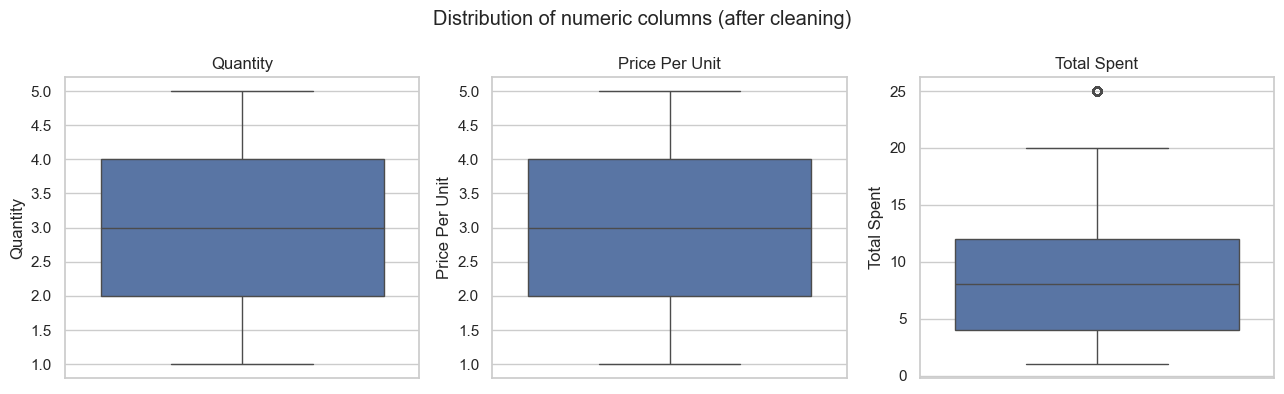

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.suptitle("Distribution of numeric columns (after cleaning)")
plt.tight_layout()
plt.savefig("images/boxplots.png", dpi=120)
plt.show()

In [21]:
print("Transactions with Total Spent above the IQR upper bound:")
upper = outliers.loc["Total Spent", "IQR upper"]
df.loc[df["Total Spent"] > upper, ["Item", "Quantity", "Price Per Unit", "Total Spent"]].value_counts()

Transactions with Total Spent above the IQR upper bound:


Item   Quantity  Price Per Unit  Total Spent
Salad  5.0       5.0             25.0           259
Name: count, dtype: int64

**Decision: retain all values.**
The only values flagged by the IQR method are the highest `Total Spent` values (25.0), which correspond to **5 salads at 5.0** — a perfectly realistic order (e.g. a group lunch). They respect both business rules (menu price and Total = Quantity × Price), and the Z-score method flags nothing. Removing or capping them would **under-estimate the café's revenue**. These are *natural extremes*, not errors.

## 7. Final Data Types & Validation

In [22]:
df["Quantity"] = df["Quantity"].astype(int)
df = df.sort_values("Transaction Date").reset_index(drop=True)

# Automatic checks — the notebook stops with an error if one of them fails
assert df.isna().sum().sum() == 0, "missing values remain"
assert df["Transaction ID"].is_unique, "duplicate IDs"
assert np.allclose(df["Quantity"] * df["Price Per Unit"], df["Total Spent"]), "Total ≠ Q × P"
known = df["Item"] != "Unknown"
assert (df.loc[known, "Item"].map(menu) == df.loc[known, "Price Per Unit"]).all(), "price ≠ menu"
print("✅ All validation checks passed")
df.info()

✅ All validation checks passed
<class 'pandas.DataFrame'>
RangeIndex: 9534 entries, 0 to 9533
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9534 non-null   string        
 1   Item              9534 non-null   str           
 2   Quantity          9534 non-null   int64         
 3   Price Per Unit    9534 non-null   float64       
 4   Total Spent       9534 non-null   float64       
 5   Payment Method    9534 non-null   str           
 6   Location          9534 non-null   str           
 7   Transaction Date  9534 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(3), string(1)
memory usage: 596.0 KB


In [23]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_8249251,Cake,3,3.0,9.0,Unknown,In-store,2023-01-01
1,TXN_3093284,Coffee,4,2.0,8.0,Digital Wallet,In-store,2023-01-01
2,TXN_5728991,Salad,2,5.0,10.0,Unknown,Unknown,2023-01-01
3,TXN_7367474,Juice,5,3.0,15.0,Digital Wallet,Takeaway,2023-01-01
4,TXN_2104473,Cake,3,3.0,9.0,Digital Wallet,Takeaway,2023-01-01
5,TXN_6093955,Tea,5,1.5,7.5,Unknown,Takeaway,2023-01-01
6,TXN_1604072,Coffee,2,2.0,4.0,Unknown,Unknown,2023-01-01
7,TXN_2192787,Sandwich,5,4.0,20.0,Cash,In-store,2023-01-01
8,TXN_1581562,Coffee,2,2.0,4.0,Cash,In-store,2023-01-01
9,TXN_2024598,Sandwich,1,4.0,4.0,Digital Wallet,In-store,2023-01-01


## 8. Before vs. After Summary

In [24]:
EXPECTED = {
    "Transaction ID": "string", "Item": "string", "Quantity": "int",
    "Price Per Unit": "float", "Total Spent": "float",
    "Payment Method": "string", "Location": "string", "Transaction Date": "datetime",
}

def dtype_ok(s, expected):
    return {
        "string": pd.api.types.is_string_dtype(s),
        "int": pd.api.types.is_integer_dtype(s),
        "float": pd.api.types.is_float_dtype(s),
        "datetime": pd.api.types.is_datetime64_any_dtype(s),
    }[expected]

def summary(d):
    correct = sum(dtype_ok(d[c], t) for c, t in EXPECTED.items())
    return {
        "Row count": len(d),
        "Null count (NaN)": int(d.isna().sum().sum()),
        "Placeholder count (ERROR/UNKNOWN)": int(d.isin(PLACEHOLDERS).sum().sum()),
        "Duplicate rows": int(d.duplicated().sum()),
        "Duplicate IDs": int(d["Transaction ID"].duplicated().sum()),
        "Columns with correct dtype": f"{correct}/{len(EXPECTED)} ({correct / len(EXPECTED):.0%})",
    }

comparison = pd.DataFrame({"Before": summary(raw), "After": summary(df)})
comparison

,Before,After
Row count,10000,9534
Null count (NaN),6826,0
Placeholder count (ERROR/UNKNOWN),3256,0
Duplicate rows,0,0
Duplicate IDs,0,0
Columns with correct dtype,4/8 (50%),8/8 (100%)


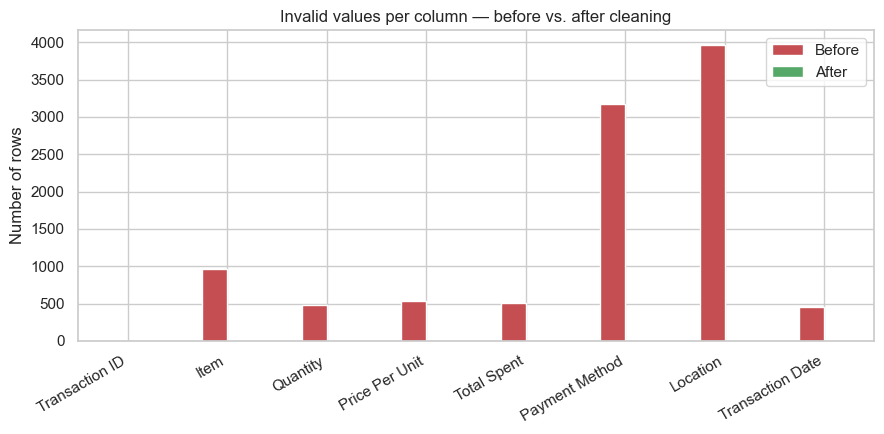

In [25]:
before = raw.isna().sum() + raw.isin(PLACEHOLDERS).sum()
after = df.isna().sum()          # "Unknown" is a deliberate category, not a missing value
fig, ax = plt.subplots(figsize=(9, 4.5))
pd.DataFrame({"Before": before, "After": after}).plot(kind="bar", ax=ax, color=["#C44E52", "#55A868"])
ax.set_title("Invalid values per column — before vs. after cleaning")
ax.set_ylabel("Number of rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("images/before_after.png", dpi=120)
plt.show()

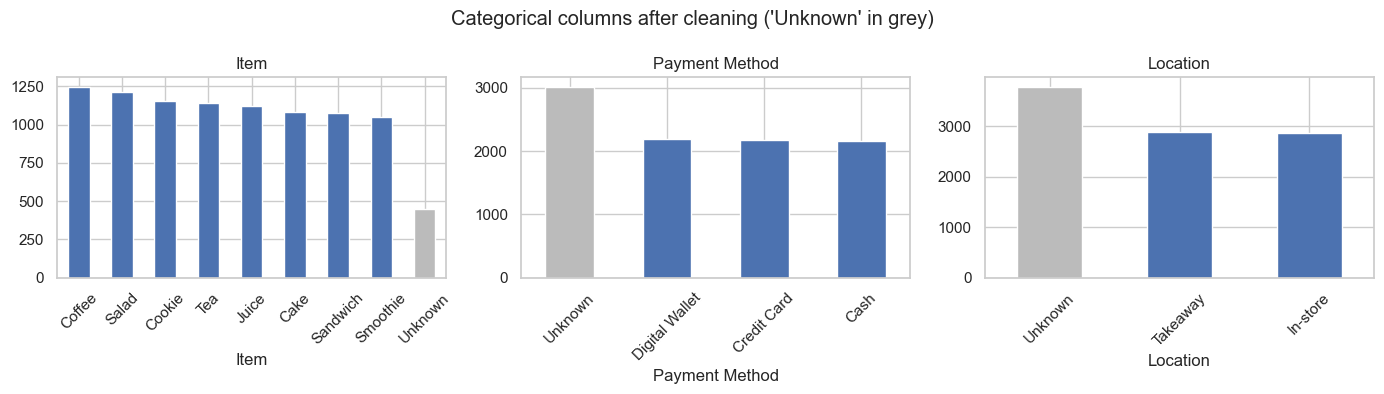

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Item", "Payment Method", "Location"]):
    counts = df[col].value_counts()
    colors = ["#BBBBBB" if v == "Unknown" else "#4C72B0" for v in counts.index]
    counts.plot(kind="bar", ax=ax, color=colors)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Categorical columns after cleaning ('Unknown' in grey)")
plt.tight_layout()
plt.savefig("images/categories_after.png", dpi=120)
plt.show()

## 9. Export

In [27]:
df.to_csv("data/cleaned.csv", index=False)
print("Saved data/cleaned.csv —", df.shape)

Saved data/cleaned.csv — (9534, 8)


## ✅ Conclusion
- The raw dataset looked complete (10,000 rows, no `NaN` in some columns) but actually hid **thousands of invalid values** behind the `"ERROR"` and `"UNKNOWN"` placeholders, and **every column was stored as text**.
- Discovering two **business rules** (fixed menu prices and Total = Quantity × Price) was the key step: it allowed us to **recover most missing numeric values exactly**, instead of imputing them.
- Each remaining problem received a **justified** strategy: row deletion for missing dates, median imputation for the few remaining quantities, and an explicit `"Unknown"` category for categorical columns where guessing would bias the analysis.
- The final dataset has **no missing values, no duplicates, correct data types** for all columns, and passes automatic consistency checks. It is ready for exploratory analysis (e.g. monthly revenue, best-selling items, payment preferences).

**Limitations:** ~4.6 % of transactions were removed because their date was unknown, and the `"Unknown"` categories (especially for `Location` and `Payment Method`) must be kept in mind when drawing conclusions about those variables.